# 01  -  Exploratory Data Analysis

**Goal:** Understand the feature matrix before any modelling.
Three questions drive every section:
1. Are per-species distributions what biology predicts?
2. Is the published RESTRICT/FACILITATE pattern (RM ↔ ARG) visible in the new species?
3. Which features vary between species (Q1 signal) vs within species (Q2 signal)?

**Sections:**
1. Per-species summary statistics  -  confirm the numbers make sense
2. Defence system prevalence  -  which systems exist in which species?
3. RESTRICT/FACILITATE check  -  Spearman correlations per species vs published findings
4. Variance decomposition  -  between-species vs within-species feature variance

## Imports and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

ROOT    = Path("..")
PROC    = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load feature matrix ───────────────────────────────────────────────────
fm = pd.read_parquet(PROC / "feature_matrix_3460.parquet")

# ── Column groups ──────────────────────────────────────────────────────────
dp_cols    = [c for c in fm.columns if c.startswith("dp_")]   # defence P/A (274)
dc_cols    = [c for c in fm.columns if c.startswith("dc_")]   # defence counts (274)
ad_cols    = [c for c in fm.columns if c.startswith("ad_")]   # anti-defence P/A (29)
label_cols = ["species", "arg_burden_tertile", "country",
              "year_bin", "complex_member", "sequence_type", "mlst_scheme"]

# Shorthand: features only (no label cols)
feat_cols  = [c for c in fm.columns if c not in label_cols]

SPECIES_ORDER = ["kpneumoniae", "ecloaceae", "abaumannii",
                 "efaecium", "paeruginosa", "saureus"]

SPECIES_LABELS = {
    "kpneumoniae": "K. pneumoniae",
    "ecloaceae":   "E. cloacae complex",
    "abaumannii":  "A. baumannii",
    "efaecium":    "E. faecium",
    "paeruginosa": "P. aeruginosa",
    "saureus":     "S. aureus",
}

print(f"Feature matrix loaded: {fm.shape[0]} genomes × {fm.shape[1]} columns")
print(f"  Feature columns:  {len(feat_cols)}")
print(f"  Label columns:    {len(label_cols)}")
print(f"  Species: {fm['species'].value_counts().to_dict()}")

Feature matrix loaded: 878 genomes × 631 columns
  Feature columns:  624
  Label columns:    7
  Species: {'saureus': 150, 'paeruginosa': 150, 'abaumannii': 150, 'efaecium': 150, 'ecloaceae': 146, 'kpneumoniae': 132}


## Section 1  -  Per-species summary statistics

### What we are looking for and why

Before plotting anything, read the numbers. A table of medians and IQRs tells you:
- Whether each species has the ARG and defence burden you expect from the literature
- Whether any species has near-zero variance on a key feature (which would make it
  uninformative for that species' modelling)
- Whether the published *Acinetobacter* finding is consistent with the new species
  at a glance  -  A. baumannii should have the *fewest* defence systems and relatively
  *high* ARG burden, because IC2 clones have depauperate defence repertoires that
  allow MGE entry

**Key variables to summarise:**
- `defence_system_count`  -  how many distinct defence types per genome
- `arg_count_unique`  -  how many distinct ARGs per genome (Q2 target)
- `ime_count_unique`  -  how many distinct ICE/IME elements
- `is_count_total`  -  total IS elements (abundant MGE proxies)
- `adef_system_count`  -  anti-defence system count (proxy for anti-defence burden)

**What we do NOT do here:** We do not test significance yet. Descriptive statistics
first; inference in Phase 6+. This is the same discipline as checking your gel
before running the Western blot analysis.

In [2]:
# ── Core count variables to summarise ────────────────────────────────────────
SUMMARY_VARS = [v for v in [
    "defence_system_count",
    "arg_count_unique",
    "ime_count_unique",
    "is_count_total",        # excluded if ISEScan incomplete
    "adef_system_count",
    "hmrg_metal_total",
] if v in fm.columns]

# ── Per-species summary table: median [IQR], min–max ─────────────────────────
rows = []
for sp in SPECIES_ORDER:
    sub = fm[fm["species"] == sp]
    row = {"species": SPECIES_LABELS[sp], "n": len(sub)}
    for v in SUMMARY_VARS:
        q1  = sub[v].quantile(0.25)
        med = sub[v].median()
        q3  = sub[v].quantile(0.75)
        mn  = sub[v].min()
        mx  = sub[v].max()
        row[v] = f"{med:.0f} [{q1:.0f}–{q3:.0f}]  ({mn:.0f}–{mx:.0f})"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("species")

print("Per-species summary: median [IQR]  (min–max)")
print("=" * 90)
print(summary_df.to_string())
print()
print("Column key:")
print("  defence_system_count : distinct defence types in genome")
print("  arg_count_unique     : distinct ARG genes (ResFinder)")
print("  ime_count_unique     : distinct ICE/IME elements (ICEberg)")
print("  is_count_total       : total IS elements (ISEScan)")
print("  adef_system_count    : anti-defence system count (DF anti-defence)")
print("  hmrg_metal_total     : metal resistance genes (AMRFinderPlus)")

Per-species summary: median [IQR]  (min–max)
                      n defence_system_count   arg_count_unique    ime_count_unique          is_count_total adef_system_count   hmrg_metal_total
species                                                                                                                                         
K. pneumoniae       132  22 [19–27]  (10–36)  15 [8–20]  (4–34)  17 [12–19]  (1–21)     60 [42–76]  (0–132)   5 [3–6]  (1–10)  20 [7–23]  (2–54)
E. cloacae complex  146   16 [13–19]  (7–30)   6 [2–14]  (0–26)   15 [1–18]  (0–46)     42 [16–61]  (0–261)    2 [1–3]  (0–7)  19 [4–30]  (1–65)
A. baumannii        150     6 [3–10]  (1–20)  10 [6–12]  (2–19)   11 [9–13]  (0–17)     40 [22–51]  (0–156)    3 [1–3]  (0–4)     1 [1–1]  (0–8)
E. faecium          150     8 [6–10]  (2–16)   8 [6–10]  (1–16)  12 [11–14]  (1–16)  154 [116–183]  (0–237)    2 [2–2]  (0–2)     1 [1–1]  (0–8)
P. aeruginosa       150   14 [10–20]  (5–33)   6 [5–11]  (5–29)    2 [1–16]  (1–23)  

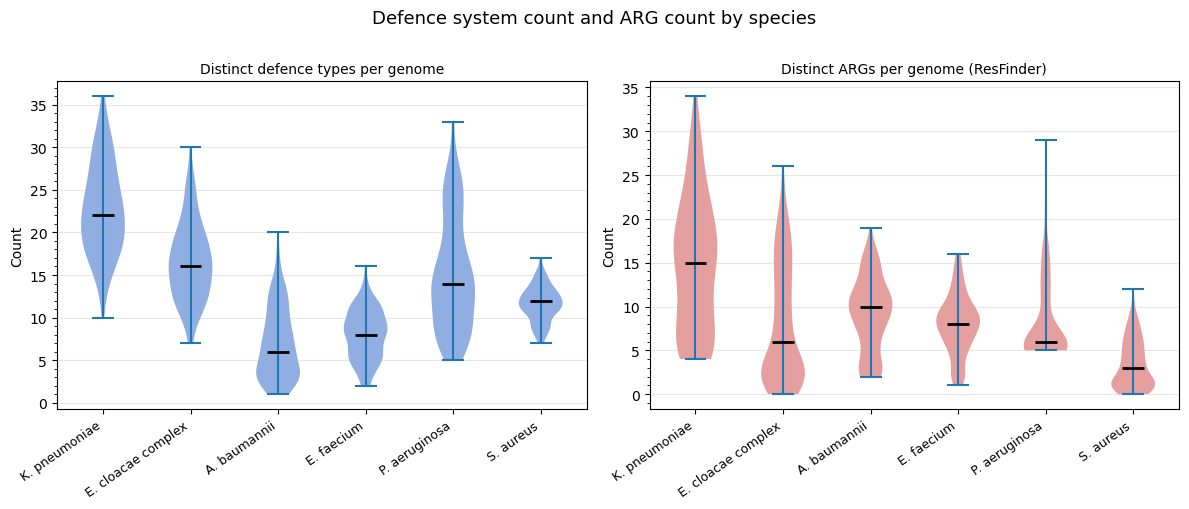

Saved: results/figures/eda/01_defence_arg_violin.png


In [3]:
# ── Violin plots: defence_system_count and arg_count_unique side by side ──────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Defence system count and ARG count by species", fontsize=13, y=1.01)

sp_labels = [SPECIES_LABELS[s] for s in SPECIES_ORDER]

for ax, var, title, colour in zip(
    axes,
    ["defence_system_count", "arg_count_unique"],
    ["Distinct defence types per genome", "Distinct ARGs per genome (ResFinder)"],
    ["#4878CF", "#D65F5F"],
):
    data_by_sp = [fm[fm["species"] == sp][var].values for sp in SPECIES_ORDER]
    parts = ax.violinplot(data_by_sp, positions=range(len(SPECIES_ORDER)),
                          showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(colour)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks(range(len(SPECIES_ORDER)))
    ax.set_xticklabels(sp_labels, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_defence_arg_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/01_defence_arg_violin.png")

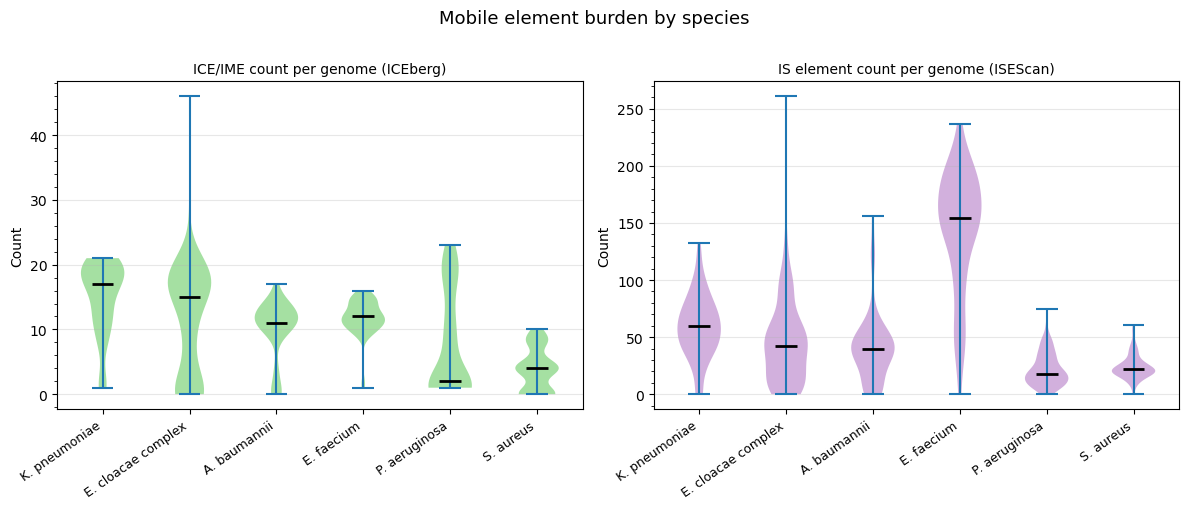

Saved: results/figures/eda/02_ime_is_violin.png


In [4]:
# ── IME and IS counts  -  the MGE burden landscape ─────────────────────────────
_mge = [(v, t, c) for v, t, c in [
    ("ime_count_unique", "ICE/IME count per genome (ICEberg)", "#6ACC65"),
    ("is_count_total",   "IS element count per genome (ISEScan — excluded if incomplete)", "#B47CC7"),
] if v in fm.columns]
_n = len(_mge)
fig, _axes = plt.subplots(1, _n, figsize=(6*_n, 5))
axes = [_axes] if _n == 1 else list(_axes)
fig.suptitle("Mobile element burden by species", fontsize=13, y=1.01)

for ax, (var, title, colour) in zip(axes, _mge):
    data_by_sp = [fm[fm["species"] == sp][var].values for sp in SPECIES_ORDER]
    parts = ax.violinplot(data_by_sp, positions=range(len(SPECIES_ORDER)),
                          showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(colour)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks(range(len(SPECIES_ORDER)))
    ax.set_xticklabels(sp_labels, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_ime_is_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/02_ime_is_violin.png")

### What to read from these plots

Each violin shows the *distribution shape*, not just the mean. The thick horizontal
line inside each violin is the **median**. Wide bellies = many genomes at that count;
narrow extensions = a few outliers.

**Checklist before moving to Section 2:**
- Does A. baumannii have the lowest `defence_system_count`? (Expected from the paper)
- Does K. pneumoniae have the highest ARG burden? (Consistent with its clinical
  reputation as a high-MDR species)
- Does P. aeruginosa have the lowest IME count despite having a reasonably high
  defence count? (Suggests active defence restriction of IMEs in PA)
- Does E. faecium have anomalously high IS element counts?
  (If yes: gram-positive IS-driven MGE acquisition pathway)

Surprises from this plot become hypotheses to test in Section 3.

### Section 1 comprehension check

Answer before Section 2.

**Q1.** The median defence_system_count for A. baumannii is 6  -  the lowest across all
six ESKAPE species. The median for K. pneumoniae is 22. Does this mean KP genomes are
*better protected* against phage than AB genomes? What other interpretation is consistent
with this observation?

**Q2.** E. faecium has median IS count = 154, roughly four times KP's median of 60.
But EF has lower IME count (median 12) than KP (median 17). What does the difference
between IS count and IME count tell you about the *type* of MGE activity in EF vs KP?

**Q3.** You see that defence_system_count and arg_count_unique are both highest in
K. pneumoniae. If you ran a Spearman correlation on the pooled 878-genome dataset
(all species together), would you expect a positive or negative correlation between
these two variables  -  and why might that pooled correlation be misleading?

## Section 2  -  Defence system prevalence

### What we are looking for and why

The summary table in Section 1 told you *how many* defence systems each species
carries on average. This section reveals *which* systems they are.

**The core question:** Are defence systems species-specific (each species has its own
repertoire) or generalist (the same systems appear across all six species)?

If defence systems are species-specific, Q1 classification (predict species from
defence repertoire) will work easily. If they are generalist, the classifier must
find subtle *abundance* differences rather than presence/absence differences.

**What we plot:** A heatmap where:
- Rows = individual defence system types (274 total from DefenseFinder)
- Columns = the six ESKAPE species
- Cell colour = fraction of genomes in that species carrying that system (0–1)
- Rows are hierarchically clustered so systems with similar prevalence patterns
  cluster together  -  the clustering itself is biologically informative

**Three things to read from this plot:**
1. Near-universal systems (hot across all columns): present in >80% of genomes
   of every species  -  uninformative for Q1 but may be important for Q2 if they
   vary in count
2. Species-exclusive systems (hot in one column, cold in all others): these are
   Q1's strongest features. If a system appears in 90% of PA genomes and 0% of
   AB genomes, it nearly classifies the species on its own
3. The A. baumannii column: should be notably sparser than others, consistent
   with the published paper's finding of depauperate AB defence repertoires

In [5]:
# ── Compute per-species prevalence for each defence system type ───────────────
# dp_* columns are binary (0/1). Mean per species = fraction of genomes carrying
# each system. Result: 274 systems × 6 species matrix.

dp_cols = [c for c in fm.columns if c.startswith("dp_")]

prev = pd.DataFrame(
    {sp: fm[fm["species"] == sp][dp_cols].mean() for sp in SPECIES_ORDER},
    index=dp_cols,
)
prev.index = [c.replace("dp_", "") for c in prev.index]  # strip prefix for legibility
prev.columns = [SPECIES_LABELS[s] for s in SPECIES_ORDER]

print(f"Prevalence matrix shape: {prev.shape}  (defence types × species)")
print()

# ── How many systems are near-universal? (>80% in all 6 species) ─────────────
near_universal = prev[(prev > 0.80).all(axis=1)]
print(f"Near-universal systems (>80% in ALL 6 species): {len(near_universal)}")
if len(near_universal):
    print(near_universal.to_string())
print()

# ── How many are completely absent from AB? (prevalence = 0) ─────────────────
ab_absent = prev[prev["A. baumannii"] == 0]
print(f"Systems absent from ALL A. baumannii genomes: {len(ab_absent)}")
print()

# ── Top 10 most prevalent systems per species ─────────────────────────────────
print("Top 5 most prevalent systems per species:")
for sp_label in [SPECIES_LABELS[s] for s in SPECIES_ORDER]:
    top5 = prev[sp_label].nlargest(5)
    print(f"  {sp_label}:")
    for sys_name, val in top5.items():
        print(f"    {sys_name:<35} {val:.2f}")
    print()

Prevalence matrix shape: (274, 6)  (defence types × species)

Near-universal systems (>80% in ALL 6 species): 0

Systems absent from ALL A. baumannii genomes: 147

Top 5 most prevalent systems per species:
  K. pneumoniae:
    padloc_PDC-S07                      1.00
    padloc_PDC-S04                      0.99
    padloc_PDC-S12                      0.99
    VSPR                                0.98
    AbiE                                0.92

  E. cloacae complex:
    padloc_PDC-S07                      0.99
    VSPR                                0.99
    padloc_PDC-S12                      0.98
    PD-T4-6                             0.97
    RM_Type_I                           0.54

  A. baumannii:
    SspBCDE                             0.51
    padloc_PDC-S15                      0.37
    RM_Type_I                           0.33
    Gao_Qat                             0.32
    PD-T4-5                             0.28

  E. faecium:
    AbiE                                0.86
  

Systems with any presence: 274 of 274


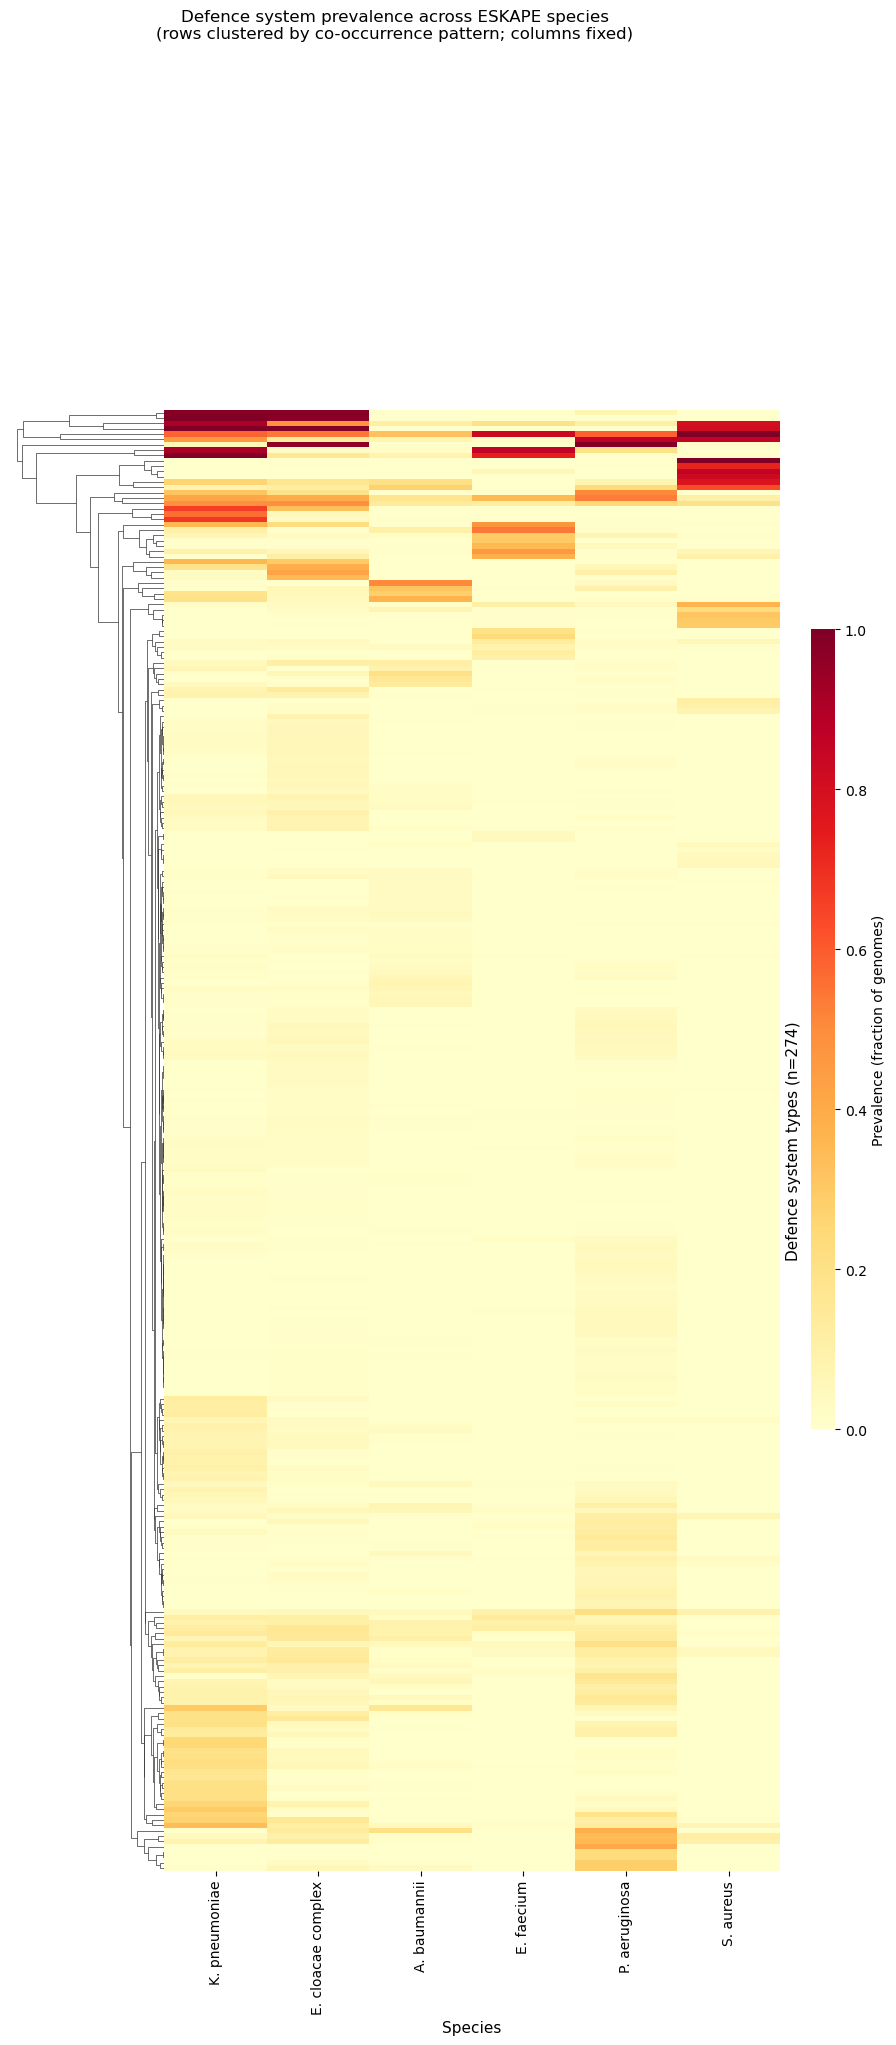

Saved: results/figures/eda/03_defence_prevalence_heatmap.png


In [6]:
# ── Full prevalence heatmap (hierarchically clustered rows) ──────────────────
# seaborn clustermap clusters both rows and columns by default.
# col_cluster=False keeps species in our fixed order.
# Row clustering groups systems with similar cross-species patterns.

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Filter: keep only systems present in ≥1 genome (prevalence > 0 in any species)
prev_nonzero = prev[(prev > 0).any(axis=1)]
print(f"Systems with any presence: {len(prev_nonzero)} of {len(prev)}")

g = sns.clustermap(
    prev_nonzero,
    col_cluster=False,         # keep species columns in SPECIES_ORDER
    row_cluster=True,          # cluster defence types by co-occurrence pattern
    cmap="YlOrRd",
    figsize=(8, 20),
    xticklabels=True,
    yticklabels=False,         # 274 labels illegible at this size
    linewidths=0,
    cbar_pos=(1.02, 0.3, 0.03, 0.4),
    cbar_kws={"label": "Prevalence (fraction of genomes)"},
)
g.ax_heatmap.set_xlabel("Species", fontsize=11)
g.ax_heatmap.set_ylabel(f"Defence system types (n={len(prev_nonzero)})", fontsize=11)
g.fig.suptitle(
    "Defence system prevalence across ESKAPE species\n"
    "(rows clustered by co-occurrence pattern; columns fixed)",
    y=1.01, fontsize=12,
)
plt.savefig(FIG_DIR / "03_defence_prevalence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/03_defence_prevalence_heatmap.png")

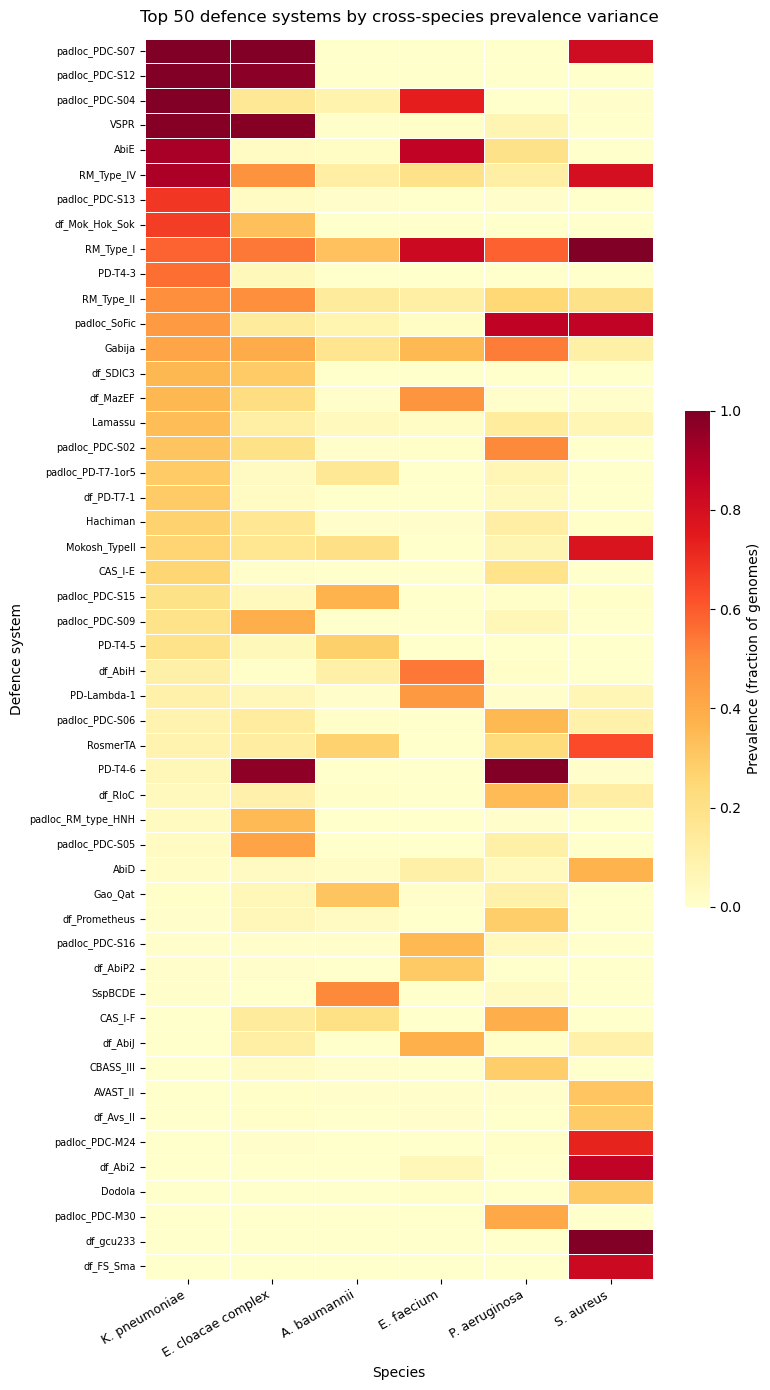

Saved: results/figures/eda/04_defence_prevalence_top50.png


In [7]:
# ── Zoom heatmap: top 50 systems by cross-species variance ────────────────────
# The full heatmap has 274 rows  -  most of them near-zero.
# Selecting systems with high cross-species variance shows the discriminating ones.

row_variance = prev_nonzero.var(axis=1)
top50 = prev_nonzero.loc[row_variance.nlargest(50).index]
top50 = top50.sort_values(by=list(top50.columns), ascending=False)

fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(
    top50,
    ax=ax,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.4,
    linecolor="white",
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "Prevalence (fraction of genomes)", "shrink": 0.4},
)
ax.set_title(
    "Top 50 defence systems by cross-species prevalence variance",
    fontsize=12, pad=12,
)
ax.set_xlabel("Species", fontsize=10)
ax.set_ylabel("Defence system", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_defence_prevalence_top50.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/04_defence_prevalence_top50.png")

In [8]:
# ── Check prevalence of the published key systems in all 6 species ────────────
# The JAM paper identified RM systems, SspBCDE, and Gao_Qat as the main
# discriminating systems in Acinetobacter. Check if they appear in the other
# five species  -  if yes, cross-species generalisation is plausible.

KEY_SYSTEMS = [
    "RM_Type_I",
    "RM_Type_II",
    "RM_Type_III",
    "RM_Type_IV",
    "SspBCDE",
    "Gao_Qat",
    "Gabija",
    "Druantia",
    "Lamassu",
    "Thoeris",
    "Zorya",
    "CRISPR_Cas",
]

found_systems = [s for s in KEY_SYSTEMS if s in prev.index]
missing_systems = [s for s in KEY_SYSTEMS if s not in prev.index]

print("Published key systems  -  prevalence across species:")
print("=" * 90)
print(prev.loc[found_systems].to_string(float_format=lambda x: f"{x:.2f}"))
print()
if missing_systems:
    print(f"Not found in feature matrix (may be absent from all genomes): {missing_systems}")

Published key systems  -  prevalence across species:
             K. pneumoniae  E. cloacae complex  A. baumannii  E. faecium  P. aeruginosa  S. aureus
RM_Type_I             0.58                0.54          0.33        0.83           0.59       1.00
RM_Type_II            0.49                0.49          0.14        0.11           0.25       0.19
RM_Type_III           0.14                0.15          0.09        0.03           0.13       0.02
RM_Type_IV            0.91                0.48          0.12        0.19           0.11       0.80
SspBCDE               0.01                0.00          0.51        0.00           0.03       0.00
Gao_Qat               0.02                0.06          0.32        0.01           0.10       0.00
Gabija                0.42                0.40          0.17        0.35           0.53       0.11
Lamassu               0.34                0.11          0.05        0.02           0.13       0.07

Not found in feature matrix (may be absent from all gen

### What to read from these plots

**Full heatmap (03):** The vertical stripes of colour tell you each species'
overall defence density. A. baumannii should appear notably paler than KP.
The horizontal bands of colour are system *co-occurrence clusters*  -  groups of
systems that tend to appear together. These clusters often reflect shared MGE
carriers: if five systems are always on the same ICE, they will always be
co-present and will form a tight cluster.

**Top-50 zoom (04):** These are the systems with the highest cross-species
*variance* in prevalence  -  meaning they discriminate species most effectively.
A system that is 90% prevalent in PA but 5% in SA has high variance. These
50 systems are the ones a Q1 classifier will lean on hardest.

**Key systems table:** The published paper found RM_Type_I, SspBCDE, and
Gao_Qat as the main Acinetobacter discriminators. Their prevalence in the
other five ESKAPE species determines whether Q4 SHAP results can replicate
the published ranking. If SspBCDE appears only in AB, the SHAP comparison is
trivial. If it appears across species at variable rates, the comparison is
meaningful.

**The A. baumannii column test:** If AB is consistently the palest column in
both heatmaps, the published finding holds in the new data. If AB is not the
palest, something unexpected is in the RefSeq genome selection  -  investigate
before modelling.

### Section 2 comprehension check

**Q1.** The clustermap clusters rows (defence systems) but not columns (species).
Why is it correct to keep columns in a fixed order here rather than letting the
algorithm cluster them too?

**Q2.** You find that RM_Type_II has prevalence 0.88 in K. pneumoniae and 0.05
in A. baumannii. You also find that RM_Type_II is the top-ranked feature in the
Q1 Random Forest (Phase 7). A colleague says: "This just means the RF learned
that KP has RM and AB doesn't  -  that's phylogenetics, not defence biology. The
result is trivial." Is this critique valid? How would you respond?

**Q3.** You see a tight cluster of 8 systems that are all 0 in S. aureus and
E. faecium but present at 60–80% in the four gram-negative species. Before
looking up the system names, predict the most likely biological explanation for
this gram-stain-stratified pattern.

## Section 3  -  RESTRICT/FACILITATE check

### What we are testing and why

The published *JAM* paper's central biological claim is a **dichotomy**:
- **RESTRICT systems** (primarily RM types): negatively correlated with ARG, IME,
  and HMRG counts. These systems block MGE entry, preventing ARG acquisition.
- **FACILITATE systems** (SspBCDE, Gao_Qat): *positively* correlated with ARG
  and IME counts. These systems live on MGEs  -  they arrived in the genome via
  horizontal transfer alongside the ARGs they co-occur with.

If this dichotomy is a general principle of defence biology rather than an
*Acinetobacter*-specific phenomenon, we expect:
1. RM systems negatively correlated with ARG count **in all six ESKAPE species**
2. SspBCDE positively correlated with ARG in AB (replication), but the
   correlation is not testable in species where SspBCDE prevalence ≈ 0%
3. The per-species correlations should all be negative for RM; if any species
   shows a consistently positive RM–ARG correlation, that species is an exception
   requiring biological explanation

**What we do NOT do:** We do not pool all 878 genomes and compute one correlation.
Section 1 Q3 established why: the pooled signal is dominated by between-species
ecological differences, not within-species biology. KP has both high defence AND
high ARG, so the pooled correlation for defence vs ARG would be positive  -  the
opposite of what the RESTRICT hypothesis predicts. Per-species correlations are
the only valid test.

**Statistical note:** We use Spearman's ρ throughout, consistent with the published
paper. Defence counts are right-skewed integers; Spearman ranks, so it is
distribution-free. We apply BH correction across all tests per species (one species
at a time, correcting within the tests run for that species).

In [9]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ── Define which variables to test against ARG ────────────────────────────────
# dc_* (count) for RM types so we capture dose-dependence
# dp_* (presence) for SspBCDE and Gao_Qat because they are near-absent in most species
# and count would be mostly 0 with rare 1/2
RESTRICT_VARS = ["dc_RM_Type_I", "dc_RM_Type_II", "dc_RM_Type_III", "dc_RM_Type_IV"]
FACILITATE_VARS = ["dp_SspBCDE", "dp_Gao_Qat"]
SUMMARY_VARS_CORR = ["defence_system_count", "adef_system_count",
                     "ime_count_unique", "is_count_total"]
TARGET = "arg_count_unique"

ALL_VARS = RESTRICT_VARS + FACILITATE_VARS + SUMMARY_VARS_CORR

# ── Filter: only include vars that exist in the feature matrix ────────────────
ALL_VARS = [v for v in ALL_VARS if v in fm.columns]

print(f"Testing {len(ALL_VARS)} variables against {TARGET} per species")
print(f"Restrict: {RESTRICT_VARS}")
print(f"Facilitate: {FACILITATE_VARS}")
print()

# ── Per-species Spearman + BH correction ─────────────────────────────────────
results = []
for sp in SPECIES_ORDER:
    sub = fm[fm["species"] == sp].copy()
    rhos, pvals, var_names = [], [], []
    for var in ALL_VARS:
        if var not in sub.columns:
            continue
        # Drop rows where either variable is NaN
        pair = sub[[var, TARGET]].dropna()
        if len(pair) < 10 or pair[var].nunique() < 2:
            # Skip if too few observations or zero variance
            rho, p = np.nan, np.nan
        else:
            rho, p = spearmanr(pair[var], pair[TARGET])
        rhos.append(rho)
        pvals.append(p)
        var_names.append(var)

    # BH correction within this species
    valid = [(i, p) for i, p in enumerate(pvals) if not np.isnan(p)]
    padj = [np.nan] * len(pvals)
    if valid:
        idx_v, pv = zip(*valid)
        _, p_adj, _, _ = multipletests(list(pv), method="fdr_bh")
        for i, pa in zip(idx_v, p_adj):
            padj[i] = pa

    for var, rho, p, pa in zip(var_names, rhos, pvals, padj):
        results.append({
            "species": SPECIES_LABELS[sp],
            "variable": var,
            "rho": rho,
            "p_raw": p,
            "p_adj_BH": pa,
            "sig": "*" if pa < 0.05 else ("†" if pa < 0.10 else ""),
        })

corr_df = pd.DataFrame(results)

# ── Print per-species results for RM types ────────────────────────────────────
print("Spearman ρ: RM systems vs ARG count (per species, BH-corrected)")
print("* = FDR < 0.05    † = FDR < 0.10")
print("=" * 85)
for sp_label in [SPECIES_LABELS[s] for s in SPECIES_ORDER]:
    sp_data = corr_df[
        (corr_df["species"] == sp_label) &
        (corr_df["variable"].isin(RESTRICT_VARS + FACILITATE_VARS))
    ]
    print(f"\n{sp_label}:")
    for _, row in sp_data.iterrows():
        rho_str = f"{row['rho']:+.3f}" if not np.isnan(row["rho"]) else "  n/a "
        p_str   = f"{row['p_adj_BH']:.3f}" if not np.isnan(row["p_adj_BH"]) else "  n/a"
        print(f"  {row['variable']:<25} ρ={rho_str}  p_adj={p_str}  {row['sig']}")

Testing 10 variables against arg_count_unique per species
Restrict: ['dc_RM_Type_I', 'dc_RM_Type_II', 'dc_RM_Type_III', 'dc_RM_Type_IV']
Facilitate: ['dp_SspBCDE', 'dp_Gao_Qat']

Spearman ρ: RM systems vs ARG count (per species, BH-corrected)
* = FDR < 0.05    † = FDR < 0.10

K. pneumoniae:
  dc_RM_Type_I              ρ=+0.334  p_adj=0.000  *
  dc_RM_Type_II             ρ=+0.355  p_adj=0.000  *
  dc_RM_Type_III            ρ=-0.270  p_adj=0.003  *
  dc_RM_Type_IV             ρ=-0.126  p_adj=0.187  
  dp_SspBCDE                ρ=-0.087  p_adj=0.355  
  dp_Gao_Qat                ρ=-0.010  p_adj=0.911  

E. cloacae complex:
  dc_RM_Type_I              ρ=-0.003  p_adj=0.972  
  dc_RM_Type_II             ρ=+0.364  p_adj=0.000  *
  dc_RM_Type_III            ρ=-0.018  p_adj=0.929  
  dc_RM_Type_IV             ρ=+0.108  p_adj=0.292  
  dp_SspBCDE                ρ=  n/a   p_adj=  n/a  
  dp_Gao_Qat                ρ=+0.027  p_adj=0.929  

A. baumannii:
  dc_RM_Type_I              ρ=-0.287  p_adj=

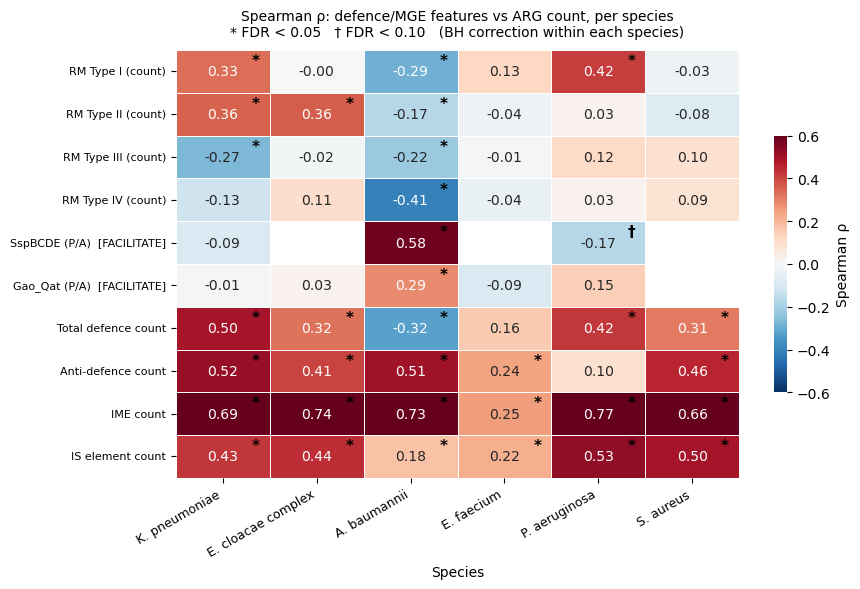

Saved: results/figures/eda/05_restrict_facilitate_heatmap.png


In [10]:
# ── Correlation heatmap: all tested variables × all species ──────────────────
pivot_rho = corr_df.pivot(index="variable", columns="species", values="rho")
pivot_sig = corr_df.pivot(index="variable", columns="species", values="sig")

# Reorder columns to SPECIES_ORDER
sp_labels_ordered = [SPECIES_LABELS[s] for s in SPECIES_ORDER]
pivot_rho = pivot_rho[sp_labels_ordered]
pivot_sig = pivot_sig[sp_labels_ordered]

# Row order: RM restrict → facilitate → summary
var_order = [v for v in RESTRICT_VARS + FACILITATE_VARS + SUMMARY_VARS_CORR
             if v in pivot_rho.index]
pivot_rho = pivot_rho.loc[var_order]
pivot_sig = pivot_sig.loc[var_order]

# Clean up row labels
row_labels = {
    "dc_RM_Type_I":        "RM Type I (count)",
    "dc_RM_Type_II":       "RM Type II (count)",
    "dc_RM_Type_III":      "RM Type III (count)",
    "dc_RM_Type_IV":       "RM Type IV (count)",
    "dp_SspBCDE":          "SspBCDE (P/A)  [FACILITATE]",
    "dp_Gao_Qat":          "Gao_Qat (P/A)  [FACILITATE]",
    "defence_system_count":"Total defence count",
    "adef_system_count":   "Anti-defence count",
    "ime_count_unique":    "IME count",
    "is_count_total":      "IS element count",
}
pivot_rho.index = [row_labels.get(v, v) for v in pivot_rho.index]
pivot_sig.index = pivot_rho.index

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    pivot_rho,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-0.6, vmax=0.6,
    annot=pivot_rho.round(2),
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Spearman ρ", "shrink": 0.6},
)

# Overlay significance stars
for row_i, row_name in enumerate(pivot_rho.index):
    for col_i, col_name in enumerate(pivot_rho.columns):
        sig = pivot_sig.loc[row_name, col_name]
        if sig:
            ax.text(col_i + 0.85, row_i + 0.25, sig,
                    ha="center", va="center", fontsize=11, color="black", weight="bold")

ax.set_title(
    "Spearman ρ: defence/MGE features vs ARG count, per species\n"
    "* FDR < 0.05   † FDR < 0.10   (BH correction within each species)",
    fontsize=10, pad=10,
)
ax.set_xlabel("Species", fontsize=10)
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_restrict_facilitate_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/05_restrict_facilitate_heatmap.png")

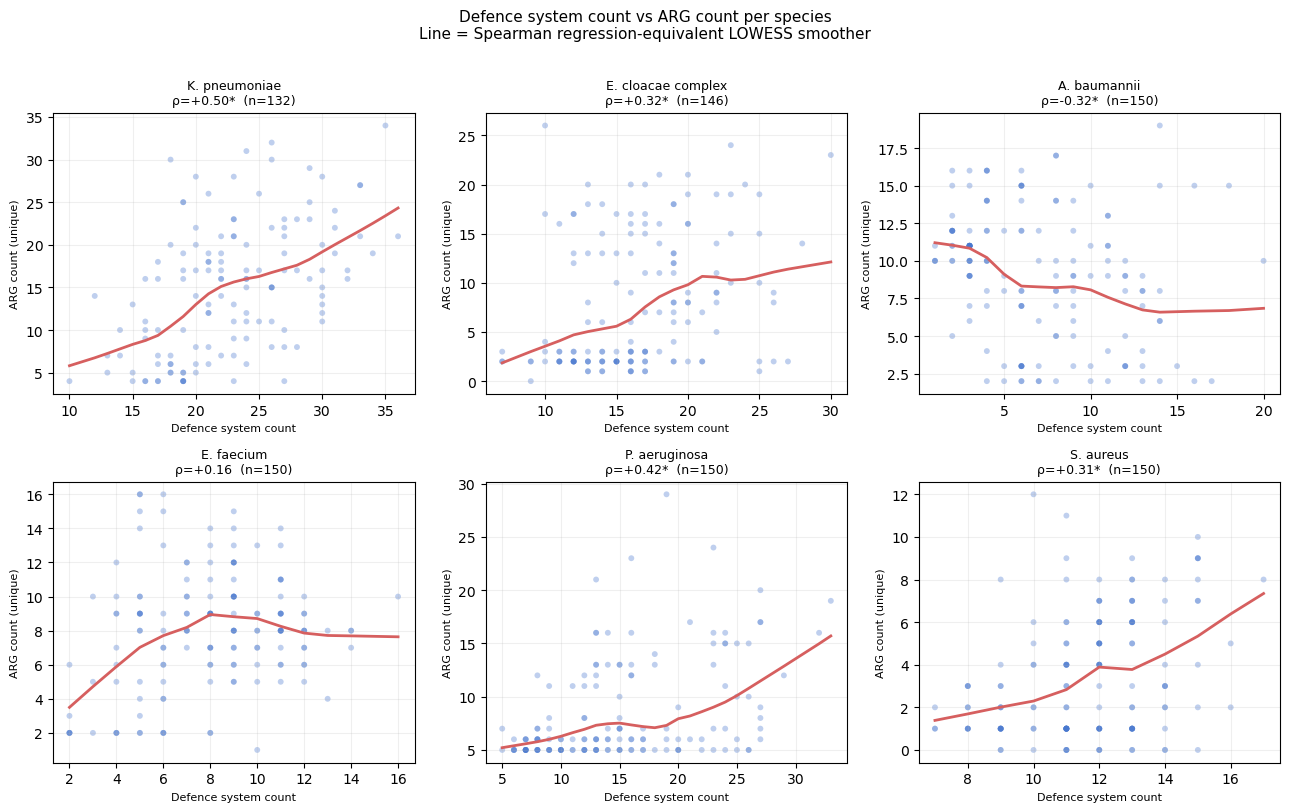

Saved: results/figures/eda/06_defence_arg_scatter_facet.png


In [11]:
# ── Scatter: defence_system_count vs arg_count_unique, faceted by species ─────
# This is the most direct visual for the RESTRICT/FACILITATE pattern:
# negative slope = more defence → fewer ARGs (RESTRICT dominates)
# positive slope = more defence → more ARGs (facilitative systems dominate)
# flat = no relationship within this species

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharey=False)
axes = axes.flatten()
fig.suptitle(
    "Defence system count vs ARG count per species\n"
    "Line = Spearman regression-equivalent LOWESS smoother",
    fontsize=11, y=1.01
)

from scipy.stats import spearmanr
import statsmodels.api as sm

for ax, sp in zip(axes, SPECIES_ORDER):
    sub = fm[fm["species"] == sp]
    x = sub["defence_system_count"].values
    y = sub["arg_count_unique"].values

    rho, p = spearmanr(x, y)
    sig_label = "*" if p < 0.05 else ""

    ax.scatter(x, y, alpha=0.35, s=18, color="#4878CF", edgecolors="none")

    # LOWESS smoother
    lowess = sm.nonparametric.lowess(y, x, frac=0.5)
    ax.plot(lowess[:, 0], lowess[:, 1], color="#D65F5F", lw=2)

    ax.set_title(
        f"{SPECIES_LABELS[sp]}\nρ={rho:+.2f}{sig_label}  (n={len(sub)})",
        fontsize=9
    )
    ax.set_xlabel("Defence system count", fontsize=8)
    ax.set_ylabel("ARG count (unique)", fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_defence_arg_scatter_facet.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/06_defence_arg_scatter_facet.png")

### How to read the RESTRICT/FACILITATE heatmap

**Negative ρ (blue cells) for RM rows = RESTRICT signal present in this species.**
The more RM systems a genome carries, the fewer ARGs it has. This is the published
*Acinetobacter* finding  -  if it generalises, all RM rows should be blue across all
six species.

**Positive ρ (red cells) for SspBCDE / Gao_Qat = FACILITATE signal.**
These are MGE-borne; genomes that acquired them via HGT also acquired ARGs on the
same mobile element. Only testable in AB where both systems have non-trivial
prevalence.

**IME count row:** Should be positive  -  more IMEs = more horizontal transfer
vehicles = more opportunity for ARG acquisition. If IME ρ is positive across
all species, this confirms IMEs as ARG vectors regardless of species.

**IS element row:** Also expected positive, but for a different reason  -  IS elements
amplify and rearrange existing ARG genes rather than importing new ones. The
relationship may be weaker than IME, or may be driven by specific IS families
(IS26 in KP being a well-known ARG-capture element).

**Exceptions:** A species with a positive RM–ARG correlation is a genuine anomaly.
It could mean RM systems in that species are on plasmids that also carry ARGs
(i.e., RM itself is the cargo of a resistance plasmid, not the gatekeeper).
Investigate before modelling.

### Section 3 comprehension check

**Q1.** The analysis reveals that RM_Type_I is negatively correlated with ARG count in
A. baumannii (ρ = −0.29, FDR < 0.001) but *positively* correlated in both K. pneumoniae
(ρ = +0.33, FDR < 0.001) and P. aeruginosa (ρ = +0.42, FDR < 0.001). In S. aureus,
the correlation is non-significant (ρ = −0.03, FDR = 0.71). Give a different biological
explanation for *each* of the three patterns: negative (AB), positive (KP/PA), and
non-significant (SA).

**Q2.** IME count vs ARG count is strongly positive in all six species:
KP ρ = +0.69, EC ρ = +0.74, AB ρ = +0.73, EF ρ = +0.25, PA ρ = +0.77, SA ρ = +0.66.
E. faecium has the weakest correlation despite having the highest IS element count
(median IS = 154). Why would IME-mediated ARG acquisition be relatively weaker in EF
than in the other five species?

**Q3.** The total defence_system_count vs ARG correlation is negative only in AB
(ρ = −0.32*) and positive in all other species (KP = +0.50*, PA = +0.42*,
EC = +0.32*, SA = +0.31*). A colleague says this means the RESTRICT/FACILITATE
hypothesis was wrong from the start and only worked in the published paper because
the dataset was too small. Construct a counter-argument that defends the AB finding
as biologically real while acknowledging the cross-species pattern.

## Section 4  -  Variance decomposition: between-species vs within-species

### What we are computing and why

Every feature column has a total variance across all 878 genomes. That variance
has two sources:
1. **Between-species variance**  -  the KP mean differs from the AB mean; the
   differences between species means drives this component.
2. **Within-species variance**  -  even within KP, not all 132 KP genomes are
   identical; genome-to-genome variation within species drives this component.

The ratio of between-species variance to total variance is **η² (eta-squared)**
from a one-way ANOVA of feature ~ species:

```
η² = SS_between / SS_total
```

- η² ≈ 1.0: almost all variance is between species → this feature is a
  **species marker**. Useful for Q1 (species classification); risky for Q2
  (predicts ARG by detecting species, not within-species biology).
- η² ≈ 0.0: almost all variance is within species → this feature varies
  primarily *within* each species. This is the signal Q2 needs  -  it reflects
  individual-genome biology, not species identity.
- η² ≈ 0.3–0.7: mixed → informative for both, but using in Q2 requires care.

**Why this matters for modelling:** If you include high-η² features in a Q2
(ARG burden) model, the model will partly classify species (which has a
predictable ARG baseline) rather than learning the within-species
defence→ARG relationship. This is a subtle form of confounding  -  not
technically leakage (test data still unseen), but biologically misleading.
The Phase 6+ models will use this decomposition to decide which features
are appropriate for Q1 vs Q2.

In [12]:
from scipy import stats as scipy_stats

feat_cols = [c for c in fm.columns if c not in
             ["species", "arg_burden_tertile", "country", "year_bin",
              "complex_member", "sequence_type", "mlst_scheme"]]

print(f"Computing η² for {len(feat_cols)} feature columns ...")

eta2_vals = {}
for col in feat_cols:
    groups = [fm[fm["species"] == sp][col].dropna().values for sp in SPECIES_ORDER]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) < 2:
        eta2_vals[col] = np.nan
        continue
    # One-way ANOVA
    grand_mean = fm[col].mean()
    ss_between = sum(
        len(g) * (g.mean() - grand_mean) ** 2 for g in groups
    )
    ss_total = sum(((v - grand_mean) ** 2) for g in groups for v in g)
    eta2_vals[col] = ss_between / ss_total if ss_total > 0 else np.nan

eta2 = pd.Series(eta2_vals, name="eta2").dropna().sort_values(ascending=False)

print(f"η² computed for {len(eta2)} features")
print()
print("Distribution of η² across all features:")
for cut, label in [(0.8, ">0.80 (strong species marker)"),
                   (0.5, "0.50–0.80 (moderate)"),
                   (0.20, "0.20–0.50 (mixed)"),
                   (0.0,  "<0.20 (mainly within-species)")]:
    n = (eta2 > cut).sum() if cut > 0 else len(eta2)
    if cut == 0.8:
        n_band = (eta2 > 0.8).sum()
    elif cut == 0.5:
        n_band = ((eta2 > 0.5) & (eta2 <= 0.8)).sum()
    elif cut == 0.20:
        n_band = ((eta2 > 0.20) & (eta2 <= 0.5)).sum()
    else:
        n_band = (eta2 <= 0.20).sum()
    print(f"  {label}: {n_band} features  ({100*n_band/len(eta2):.1f}%)")

print()
print("Top 20 features by η² (strongest species markers):")
print(eta2.head(20).to_string())
print()
print("Bottom 20 features by η² (most within-species variation):")
print(eta2.tail(20).to_string())

Computing η² for 624 feature columns ...


η² computed for 623 features

Distribution of η² across all features:
  >0.80 (strong species marker): 12 features  (1.9%)
  0.50–0.80 (moderate): 31 features  (5.0%)
  0.20–0.50 (mixed): 77 features  (12.4%)
  <0.20 (mainly within-species): 503 features  (80.7%)

Top 20 features by η² (strongest species markers):
dp_df_gcu233         0.991971
dp_padloc_PDC-S12    0.979146
ad_adf_apyc1         0.965368
dc_padloc_PDC-S07    0.955873
dp_PD-T4-6           0.927321
ad_adf_NARP1         0.920687
dc_VSPR              0.911630
dp_VSPR              0.911630
dp_padloc_PDC-S07    0.893771
dc_padloc_PDC-S12    0.891893
dc_PD-T4-6           0.866314
dc_df_gcu233         0.864836
dp_df_FS_Sma         0.798161
is_IS30_count        0.784251
is_ISNCY_count       0.775973
ad_adf_Aca_alone     0.775133
dp_df_Abi2           0.771988
is_IS982_count       0.725729
is_IS256_count       0.724423
dc_df_Abi2           0.721690

Bottom 20 features by η² (most within-species variation):
dc_df_SanaTA           0.

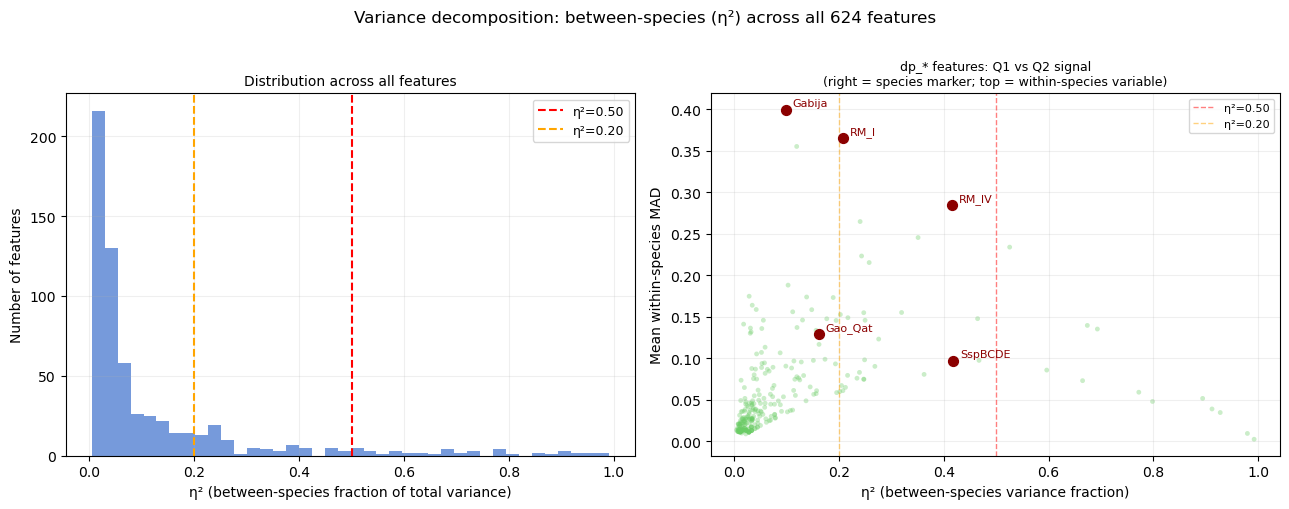

Saved: results/figures/eda/07_variance_decomposition.png


In [13]:
# ── Distribution of η² + highlight key features ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Variance decomposition: between-species (η²) across all 624 features",
             fontsize=12, y=1.01)

# Left: histogram of all η² values
ax = axes[0]
ax.hist(eta2.values, bins=40, color="#4878CF", alpha=0.75, edgecolor="none")
ax.axvline(0.5, color="red", lw=1.5, ls="--", label="η²=0.50")
ax.axvline(0.2, color="orange", lw=1.5, ls="--", label="η²=0.20")
ax.set_xlabel("η² (between-species fraction of total variance)", fontsize=10)
ax.set_ylabel("Number of features", fontsize=10)
ax.set_title("Distribution across all features", fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# Right: scatter  -  Q1 vs Q2 candidates among the dp_* and dc_* columns
# x-axis = η²; y-axis = within-species mean absolute deviation (MAD)
# Features in top-right: high between AND within variation  -  useful for both Q1 and Q2
ax2 = axes[1]

dp_eta2 = eta2[[c for c in eta2.index if c.startswith("dp_")]]
within_mad = {}
for col in dp_eta2.index:
    mads = []
    for sp in SPECIES_ORDER:
        s = fm[fm["species"] == sp][col]
        mads.append((s - s.mean()).abs().mean())
    within_mad[col] = np.mean(mads)

within_mad_s = pd.Series(within_mad)
ax2.scatter(dp_eta2.values, within_mad_s[dp_eta2.index].values,
            alpha=0.35, s=12, color="#6ACC65", edgecolors="none")

# Annotate the key published systems
key_systems = {
    "dp_SspBCDE": "SspBCDE",
    "dp_Gao_Qat": "Gao_Qat",
    "dp_RM_Type_I": "RM_I",
    "dp_RM_Type_IV": "RM_IV",
    "dp_Gabija": "Gabija",
}
for col, label in key_systems.items():
    if col in dp_eta2.index:
        ax2.annotate(
            label,
            xy=(dp_eta2[col], within_mad_s[col]),
            xytext=(5, 3), textcoords="offset points",
            fontsize=8, color="darkred",
        )
        ax2.scatter([dp_eta2[col]], [within_mad_s[col]],
                    s=50, color="darkred", zorder=5)

ax2.axvline(0.5, color="red", lw=1, ls="--", alpha=0.5, label="η²=0.50")
ax2.axvline(0.2, color="orange", lw=1, ls="--", alpha=0.5, label="η²=0.20")
ax2.set_xlabel("η² (between-species variance fraction)", fontsize=10)
ax2.set_ylabel("Mean within-species MAD", fontsize=10)
ax2.set_title("dp_* features: Q1 vs Q2 signal\n(right = species marker; top = within-species variable)",
              fontsize=9)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_variance_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/07_variance_decomposition.png")

In [14]:
# ── Where do the published key systems sit in η² space? ─────────────────────
key_cols = {
    "dp_RM_Type_I":   "RM_Type_I (P/A)",
    "dp_RM_Type_II":  "RM_Type_II (P/A)",
    "dp_RM_Type_III": "RM_Type_III (P/A)",
    "dp_RM_Type_IV":  "RM_Type_IV (P/A)",
    "dp_SspBCDE":     "SspBCDE (P/A)",
    "dp_Gao_Qat":     "Gao_Qat (P/A)",
    "dp_Gabija":      "Gabija (P/A)",
    "dc_RM_Type_I":   "RM_Type_I (count)",
    "dc_RM_Type_IV":  "RM_Type_IV (count)",
    "dc_SspBCDE":     "SspBCDE (count)" if "dc_SspBCDE" in eta2.index else None,
    "defence_system_count": "Total defence count",
    "arg_count_unique":     "ARG count (unique)  [TARGET]",
    "ime_count_unique":     "IME count (unique)",
    "is_count_total":       "IS count (total)",
}
key_cols = {k: v for k, v in key_cols.items() if v is not None and k in eta2.index}

print("η² for published key systems and summary features:")
print("=" * 65)
print(f"{'Feature':<35} {'η²':>8}   Interpretation")
print("-" * 65)
for col, label in key_cols.items():
    e = eta2[col]
    if e >= 0.8:
        interp = "strong species marker (Q1)"
    elif e >= 0.5:
        interp = "moderate species signal"
    elif e >= 0.2:
        interp = "mixed  -  both Q1 and Q2"
    else:
        interp = "mainly within-species (Q2)"
    print(f"{label:<35} {e:>8.3f}   {interp}")

η² for published key systems and summary features:
Feature                                   η²   Interpretation
-----------------------------------------------------------------
RM_Type_I (P/A)                        0.207   mixed  -  both Q1 and Q2
RM_Type_II (P/A)                       0.119   mainly within-species (Q2)
RM_Type_III (P/A)                      0.035   mainly within-species (Q2)
RM_Type_IV (P/A)                       0.415   mixed  -  both Q1 and Q2
SspBCDE (P/A)                          0.417   mixed  -  both Q1 and Q2
Gao_Qat (P/A)                          0.161   mainly within-species (Q2)
Gabija (P/A)                           0.099   mainly within-species (Q2)
RM_Type_I (count)                      0.213   mixed  -  both Q1 and Q2
RM_Type_IV (count)                     0.347   mixed  -  both Q1 and Q2
SspBCDE (count)                        0.417   mixed  -  both Q1 and Q2
Total defence count                    0.577   moderate species signal
ARG count (unique)  [T

### How to use this for modelling decisions

**High η² features (>0.5):** These will dominate Q1 classification easily.
They are risky for Q2  -  if included, the Q2 model will partly classify species
(high-ARG baseline = KP; low-ARG baseline = SA) rather than learning within-species
biology. Phase 6 will investigate whether removing high-η² features changes Q2
performance.

**Low η² features (<0.2):** These are the Q2 candidates. They vary within each
species, meaning they might discriminate high-ARG from low-ARG genomes of the
same species. These are the features the RESTRICT/FACILITATE biological story
is built on.

**The target variable (arg_count_unique) η²:** If the ARG count has high η², it
means ARG burden is largely predictable from species identity alone. If it has
low η², most of the ARG variation is within-species. This number determines how
hard Q2 actually is: if arg_count_unique η² is high, Q2 is partly a species
classification problem in disguise.

### Section 4 comprehension check

**Q1.** A feature has η² = 0.85. You include it in a Q2 (ARG burden prediction)
model trained on all 878 genomes with species as a covariate (i.e., species is
also a feature). Does the η² = 0.85 feature still cause a problem? Or does
including species as a covariate fix it?

**Q2.** arg_count_unique (the Q2 target variable) has some η². If η² were 0.80
for the target, what would this imply about the difficulty of Q2  -  and what
would you expect the null baseline accuracy to look like?

**Q3.** You find that SspBCDE has η² = 0.45. This means it has both between-species
AND within-species variance. For Q1 it might help classify AB (high prevalence)
from other species. For Q2 in AB specifically, it should correlate with high ARG
burden (per Section 3). But when you run Q2 across all species pooled, what
confound does η² = 0.45 on SspBCDE introduce  -  and how do you avoid it?